# Кейс 2. Теорема Мерсера

**Зыков Макар Романович 489608 J3211**

**Кулинич Павел Васильевич 466420 J3211**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

np.random.seed(54)

## 1. Выбор исследуемых функций

Рассмотрим следующие функции сходства

1. Линейное ядро:

$$
K_{lin}(x,z)=x^Tz
$$

2. RBF-ядро:

$$
K_{rbf}(x,z)=\exp(-\gamma \|x-z\|^2)
$$

3. Дельта-ядро:

$$
K_{\delta}(x,z)=
\begin{cases}
1, & x=z \\
0, & x \ne z
\end{cases}
$$

4. Ядро несовпадения:

$$
K_{\ne}(x,z)=
\begin{cases}
0, & x=z \\
1, & x \ne z
\end{cases}
$$

5. Сигмоидальное ядро:

$$
K_{\sigma}(x,z)=\tanh(k_0+k_1x^Tz)
$$

## 2. Предварительная гипотеза

Ожидается, что:

- линейное ядро является ядром
- RBF-ядро является ядром
- дельта-ядро является ядром
- ядро несовпадения может нарушать условие Мерсера
- сигмоидальное ядро зависит от параметров $k_0$ и $k_1$ и не всегда является корректным ядром

 Генерация синтетической выборки из 2 облаков в R^2

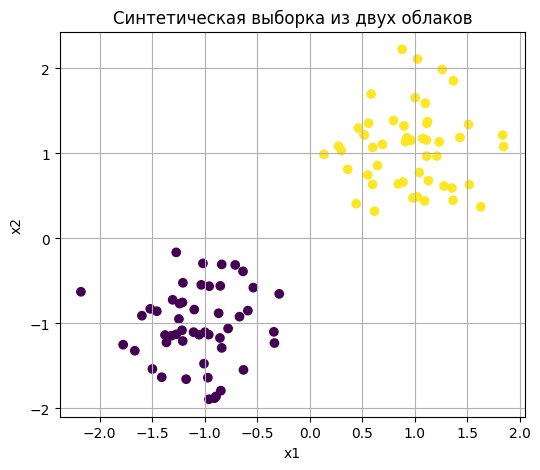

In [ ]:
def generate_two_blobs(n=100, random_state=42):
    X, y = make_blobs(
        n_samples=n,
        centers=[[-1, -1], [1, 1]],
        cluster_std=0.45,
        random_state=random_state
    )
    return X, y


X, y = generate_two_blobs(n=100)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("синтетическая выборка из двух облаков")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()

In [ ]:
def linear_kernel(X):
    return X @ X.T


def rbf_kernel(X, gamma=1.0):
    norms = np.sum(X ** 2, axis=1).reshape(-1, 1)
    distances_sq = norms + norms.T - 2 * X @ X.T
    return np.exp(-gamma * distances_sq)


def delta_kernel(X):
    n = X.shape[0]
    G = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            if np.allclose(X[i], X[j]):
                G[i, j] = 1.0
            else:
                G[i, j] = 0.0

    return G


def not_equal_kernel(X):
    return 1.0 - delta_kernel(X)


def sigmoid_kernel(X, k0=0.0, k1=1.0):
    return np.tanh(k0 + k1 * (X @ X.T))

   Анализ матрицы Грама
   
    - норма несимметричности
    - собственные значения
    - минимальное собственное значение
    - количество отрицательных собственных значений
    - случайная проверка z^T G z

In [ ]:
def analyze_gram_matrix(G, eps=1e-8, n_random_tests=1000):
    asymmetry = np.linalg.norm(G - G.T, ord="fro")

    G_sym = (G + G.T) / 2
    eigenvalues = np.linalg.eigvalsh(G_sym)

    lambda_min = np.min(eigenvalues)
    negative_count = np.sum(eigenvalues < -eps)

    random_values = []
    n = G.shape[0]

    for _ in range(n_random_tests):
        z = np.random.randn(n)
        value = z.T @ G_sym @ z
        random_values.append(value)

    random_values = np.array(random_values)

    return {
        "asymmetry": asymmetry,
        "eigenvalues": eigenvalues,
        "lambda_min": lambda_min,
        "negative_count": negative_count,
        "is_psd": lambda_min >= -eps,
        "random_min": np.min(random_values),
        "random_negative_count": np.sum(random_values < -eps)
    }

In [ ]:
kernels = {
    "Linear": linear_kernel(X),
    "RBF gamma=1": rbf_kernel(X, gamma=1.0),
    "Delta": delta_kernel(X),
    "Not equal": not_equal_kernel(X),
    "Sigmoid k0=0, k1=1": sigmoid_kernel(X, k0=0.0, k1=1.0)
}

results = []

for name, G in kernels.items():
    analysis = analyze_gram_matrix(G)

    results.append({
        "Kernel": name,
        "||G - G.T||_F": analysis["asymmetry"],
        "lambda_min": analysis["lambda_min"],
        "negative eigenvalues": analysis["negative_count"],
        "PSD condition": analysis["is_psd"],
        "min random zTGz": analysis["random_min"],
        "negative random tests": analysis["random_negative_count"]
    })

results_df = pd.DataFrame(results)
results_df

,Kernel,||G - G.T||_F,lambda_min,negative eigenvalues,PSD condition,min random zTGz,negative random tests
0,Linear,0.0,-7.836436e-14,0,True,0.103831,0
1,RBF gamma=1,0.0,2.101954e-14,0,True,9.494563,0
2,Delta,0.0,1.000000e+00,0,True,59.532208,0
3,Not equal,0.0,-1.000000e+00,99,False,-143.217219,689
4,"Sigmoid k0=0, k1=1",0.0,-3.647477e+00,23,False,-30.583384,81


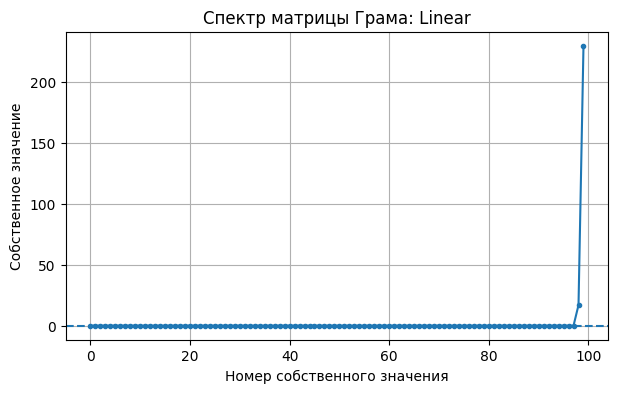

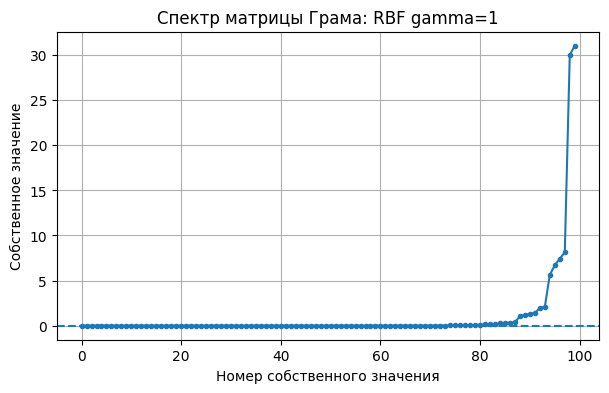

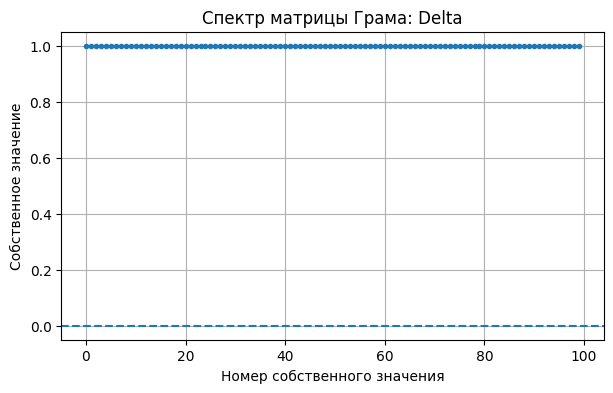

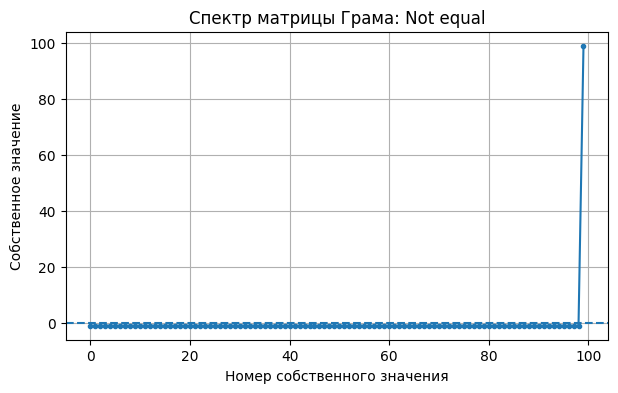

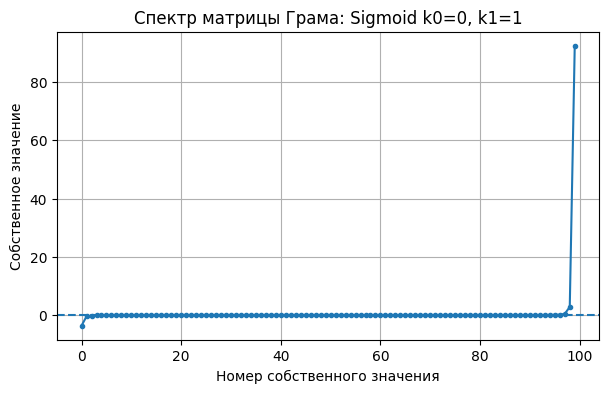

In [ ]:
for name, G in kernels.items():
    eigvals = analyze_gram_matrix(G)["eigenvalues"]

    plt.figure(figsize=(7, 4))
    plt.plot(np.sort(eigvals), marker="o", markersize=3)
    plt.axhline(0, linestyle="--")
    plt.title(f"спектр матрицы Грама: {name}")
    plt.xlabel("номер собственного значения")
    plt.ylabel("собственное значение")
    plt.grid(True)
    plt.show()

**Проверка условия Мерсера**

Если у матрицы Грама есть отрицательное собственное значение, то условие Мерсера нарушается

Действительно, пусть $\lambda < 0$ — собственное значение матрицы $G$, а $v$ — соответствующий собственный вектор. Тогда

$$
Gv=\lambda v
$$

Следовательно

$$
v^TGv=v^T\lambda v=\lambda v^Tv
$$

Так как $v^Tv>0$, а $\lambda<0$, получаем

$$
v^TGv<0
$$

Значит, существует такой вектор $v$, для которого квадратичная форма отрицательна. Поэтому матрица Грама не является положительно полуопределённой, а функция сходства нарушает условие Мерсера на данной выборке.

Однако положительная полуопределённость матрицы Грама на одной конкретной выборке ещё не доказывает, что функция является ядром в полном смысле. Для выполнения теоремы Мерсера условие должно выполняться для любой конечной выборки

In [ ]:
def print_kernel_conclusion(results_df):
    for _, row in results_df.iterrows():
        name = row["Kernel"]
        lambda_min = row["lambda_min"]
        neg = row["negative eigenvalues"]
        psd = row["PSD condition"]
        random_neg = row["negative random tests"]

        print("=" * 80)
        print(f"ядро: {name}")
        print(f"минимальное собственное значение: {lambda_min:.8f}")
        print(f"число отрицательных собственных значений: {neg}")
        print(f"случайных тестов z^T G z < 0: {random_neg}")

        if psd:
            print("вывод: на данной выборке условие Мерсера численно выполняется")
        else:
            print("вывод: на данной выборке условие Мерсера нарушается")


print_kernel_conclusion(results_df)

Ядро: Linear
Минимальное собственное значение: -0.00000000
Число отрицательных собственных значений: 0
Случайных тестов z^T G z < 0: 0
Вывод: на данной выборке условие Мерсера численно выполняется
Ядро: RBF gamma=1
Минимальное собственное значение: 0.00000000
Число отрицательных собственных значений: 0
Случайных тестов z^T G z < 0: 0
Вывод: на данной выборке условие Мерсера численно выполняется
Ядро: Delta
Минимальное собственное значение: 1.00000000
Число отрицательных собственных значений: 0
Случайных тестов z^T G z < 0: 0
Вывод: на данной выборке условие Мерсера численно выполняется
Ядро: Not equal
Минимальное собственное значение: -1.00000000
Число отрицательных собственных значений: 99
Случайных тестов z^T G z < 0: 689
Вывод: на данной выборке условие Мерсера нарушается
Ядро: Sigmoid k0=0, k1=1
Минимальное собственное значение: -3.64747702
Число отрицательных собственных значений: 23
Случайных тестов z^T G z < 0: 81
Вывод: на данной выборке условие Мерсера нарушается


**Исследование влияния параметров сигмоидального ядра**

Сигмоидальное ядро имеет вид

$$
K_{\sigma}(x,z)=\tanh(k_0+k_1x^Tz)
$$

Оно может вести себя по-разному при разных параметрах, потому что параметры $k_0$ и $k_1$ меняют аргумент функции $\tanh$.

Параметр $k_1$ отвечает за влияние скалярного произведения $x^Tz$. Если $k_1$ отрицательный, то знак сходства фактически меняется, из-за чего можно ожидать нарушение положительной полуопределённости

Параметр $k_0$ задаёт сдвиг. При отрицательных значениях $k_0$ значения ядра могут становиться отрицательными даже для близких объектов. Поэтому для отрицательных $k_0$ также можно ожидать нарушение условия Мерсера

Проверим сетку параметров:

$$
k_0 \in \{-1, 0, 1\}
$$

$$
k_1 \in \{-1, 0.1, 1\}
$$

In [ ]:
k0_values = [-1, 0, 1]
k1_values = [-1, 0.1, 1]

sigmoid_param_results = []

for k0 in k0_values:
    for k1 in k1_values:
        G = sigmoid_kernel(X, k0=k0, k1=k1)
        analysis = analyze_gram_matrix(G)

        sigmoid_param_results.append({
            "k0": k0,
            "k1": k1,
            "lambda_min": analysis["lambda_min"],
            "negative eigenvalues": analysis["negative_count"],
            "PSD condition": analysis["is_psd"]
        })

sigmoid_df = pd.DataFrame(sigmoid_param_results)
sigmoid_df

,k0,k1,lambda_min,negative eigenvalues,PSD condition
0,-1,-1.0,-82.701737,43,False
1,-1,0.1,-74.478593,15,False
2,-1,1.0,-24.400612,43,False
3,0,-1.0,-92.504080,25,False
4,0,0.1,-0.106034,9,False
5,0,1.0,-3.647477,23,False
6,1,-1.0,-82.745992,43,False
7,1,0.1,-0.518763,10,False
8,1,1.0,-5.704395,42,False


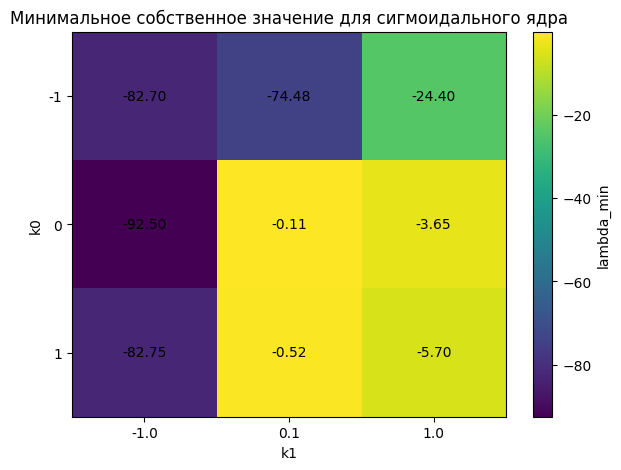

In [ ]:
heatmap_data = sigmoid_df.pivot(index="k0", columns="k1", values="lambda_min")

plt.figure(figsize=(7, 5))
plt.imshow(heatmap_data.values, aspect="auto")
plt.colorbar(label="lambda_min")
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.xlabel("k1")
plt.ylabel("k0")
plt.title("минимальное собственное значение для сигмоидального ядра")

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.values[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center")

plt.show()

**Исследование зависимости от размера выборки**

Проверим размеры выборки:

$$
n \in \{20, 50, 100, 200\}
$$

Для каждого размера построим матрицы Грама и найдём минимальные собственные значения

In [ ]:
sample_sizes = [20, 50, 100, 200]

size_results = []

for n in sample_sizes:
    X_n, y_n = generate_two_blobs(n=n, random_state=42)

    kernels_n = {
        "Linear": linear_kernel(X_n),
        "RBF gamma=1": rbf_kernel(X_n, gamma=1.0),
        "Delta": delta_kernel(X_n),
        "Not equal": not_equal_kernel(X_n),
        "Sigmoid k0=0, k1=1": sigmoid_kernel(X_n, k0=0.0, k1=1.0)
    }

    for name, G in kernels_n.items():
        analysis = analyze_gram_matrix(G)

        size_results.append({
            "n": n,
            "Kernel": name,
            "lambda_min": analysis["lambda_min"],
            "negative eigenvalues": analysis["negative_count"],
            "PSD condition": analysis["is_psd"]
        })

size_df = pd.DataFrame(size_results)
size_df

,n,Kernel,lambda_min,negative eigenvalues,PSD condition
0,20,Linear,-2.675170e-15,0,True
1,20,RBF gamma=1,2.993572e-04,0,True
2,20,Delta,1.000000e+00,0,True
3,20,Not equal,-1.000000e+00,19,False
4,20,"Sigmoid k0=0, k1=1",-8.177773e-01,9,False
5,50,Linear,-2.934725e-14,0,True
6,50,RBF gamma=1,3.135943e-09,0,True
7,50,Delta,1.000000e+00,0,True
8,50,Not equal,-1.000000e+00,49,False
9,50,"Sigmoid k0=0, k1=1",-1.928153e+00,15,False


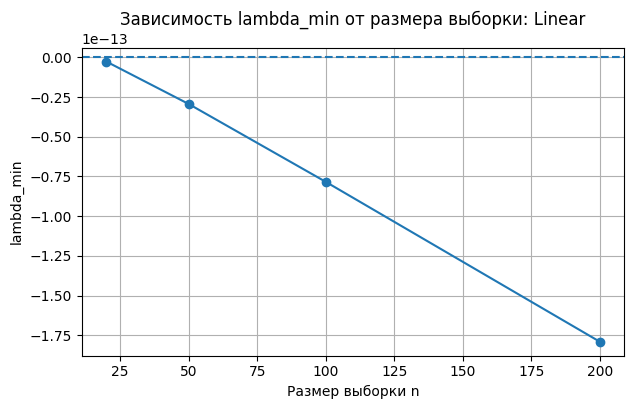

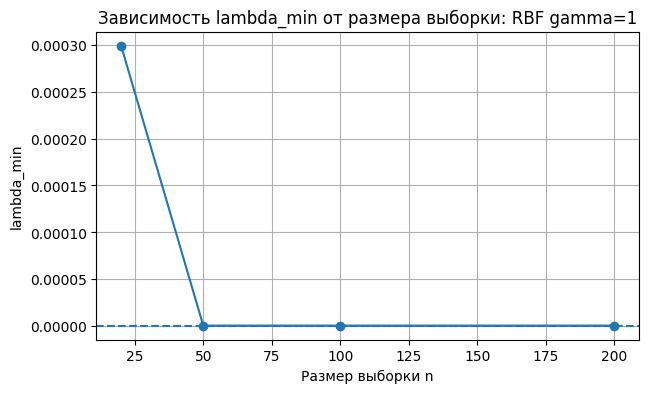

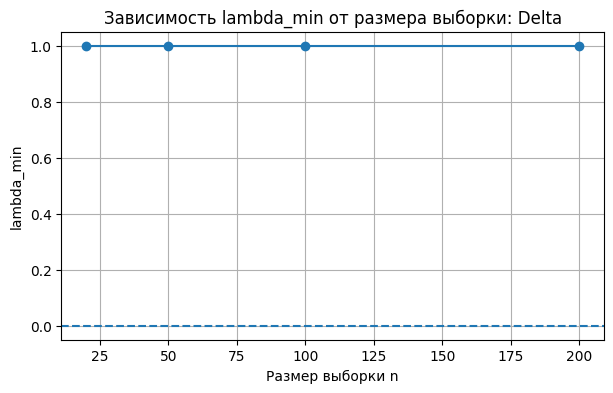

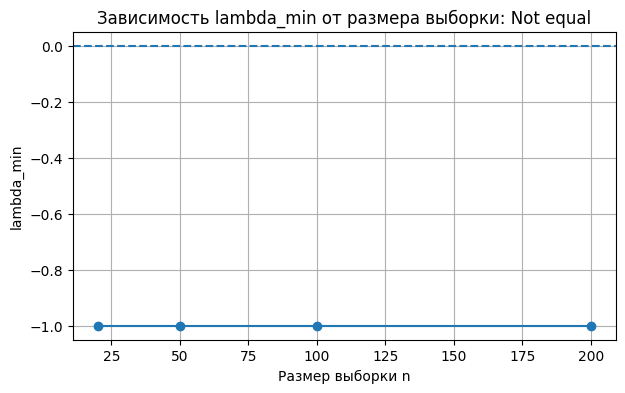

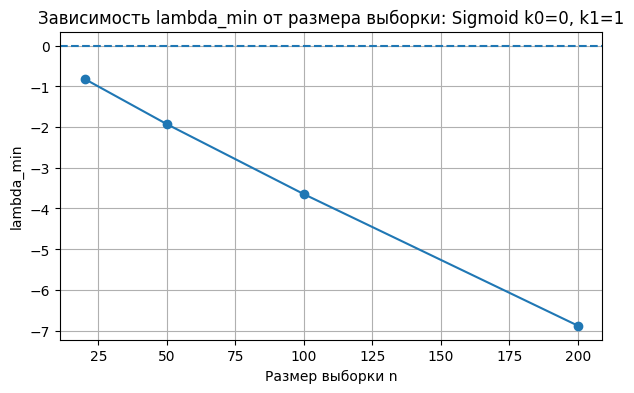

In [ ]:
for kernel_name in size_df["Kernel"].unique():
    part = size_df[size_df["Kernel"] == kernel_name]

    plt.figure(figsize=(7, 4))
    plt.plot(part["n"], part["lambda_min"], marker="o")
    plt.axhline(0, linestyle="--")
    plt.title(f"зависимость lambda min от размера выборки: {kernel_name}")
    plt.xlabel("размер выборки n")
    plt.ylabel("lambda_min")
    plt.grid(True)
    plt.show()

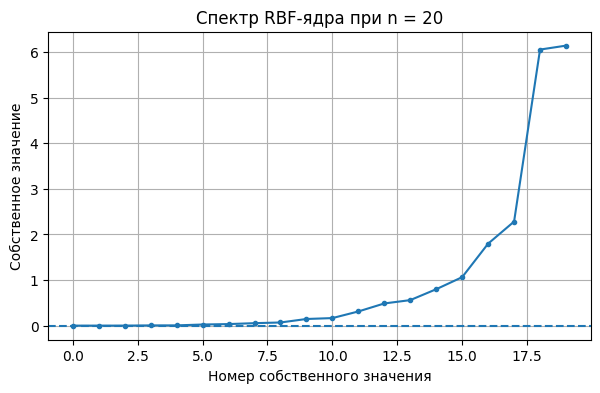

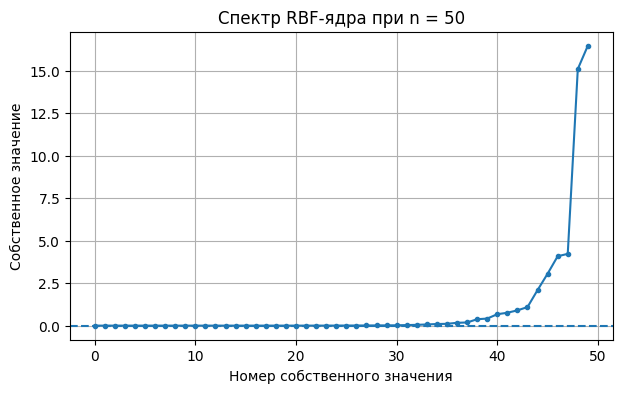

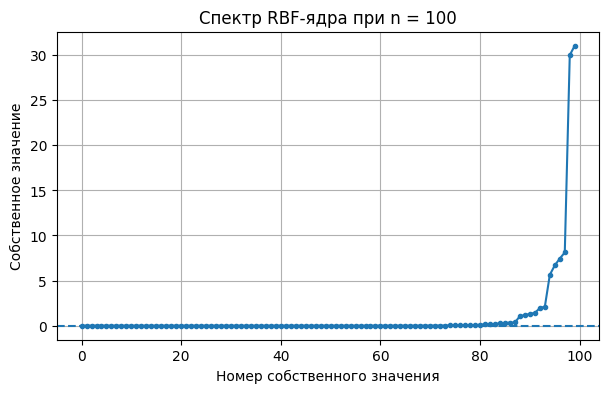

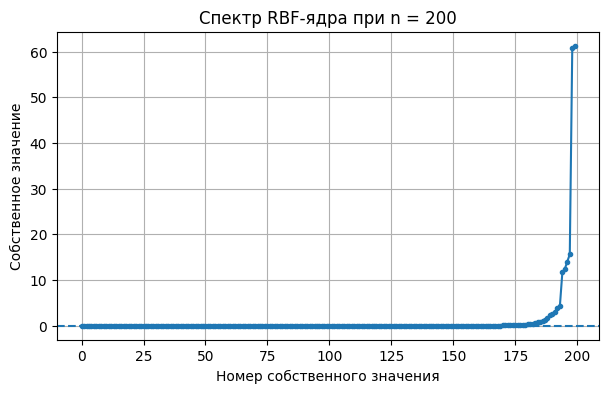

In [ ]:
for n in sample_sizes:
    X_n, y_n = generate_two_blobs(n=n, random_state=42)

    G = rbf_kernel(X_n, gamma=1.0)
    eigvals = analyze_gram_matrix(G)["eigenvalues"]

    plt.figure(figsize=(7, 4))
    plt.plot(np.sort(eigvals), marker = "o", markersize=3)
    plt.axhline(0, linestyle = "--")
    plt.title(f"спектр RBF-ядра при n = {n}")
    plt.xlabel("номер собственного значения")
    plt.ylabel("собственное значение")
    plt.grid(True)
    plt.show()

Разложение положительно полуопределённой матрицы Грама

Если матрица Грама положительно полуопределена, то все её собственные значения неотрицательны:

$$
\lambda_i \geq 0
$$

Тогда существует спектральное разложение

$$
G = Q \Lambda Q^T
$$

где $Q$ — ортогональная матрица собственных векторов, а $\Lambda$ — диагональная матрица собственных значений.

Так как $\lambda_i \geq 0$, можно корректно взять корень из собственных значений:

$$
\Lambda^{1/2}
$$

Поэтому можно представить матрицу в виде

$$
G = (Q\Lambda^{1/2})(Q\Lambda^{1/2})^T
$$

Это соответствует построению признакового представления объектов

Также для положительно определённых матриц возможно разложение Холецкого:

$$
G = LL^T
$$

Если матрица только положительно полуопределена, то классическое разложение Холецкого может потребовать малой регуляризации:

$$
G_{\varepsilon}=G+\varepsilon I
$$

Двумерная визуализация через спектральное вложение

Построим двумерное вложение объектов по положительным собственным значениям матрицы Грама

Идея:

1. строим матрицу Грама $G$
2. находим её собственные значения и собственные векторы
3. берём два наибольших положительных собственных значения
4. координаты объектов задаём как

$$
Y = V \Lambda^{1/2}
$$

где $V$ — соответствующие собственные векторы

**Спектральное вложение по положительным собственным значениям**

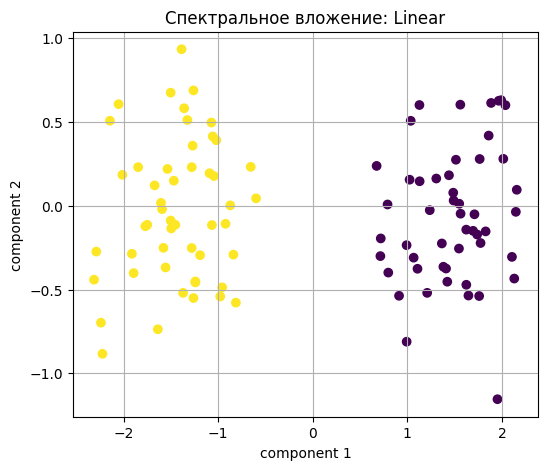

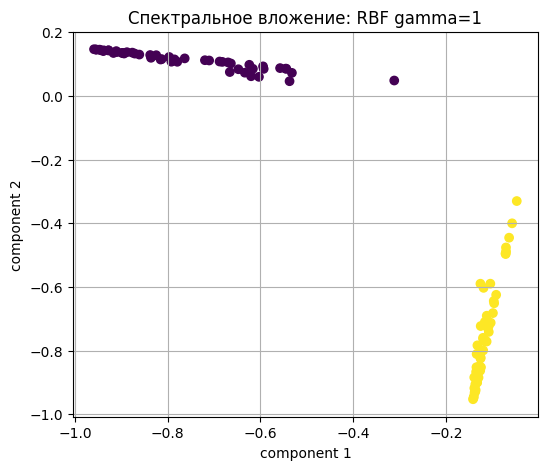

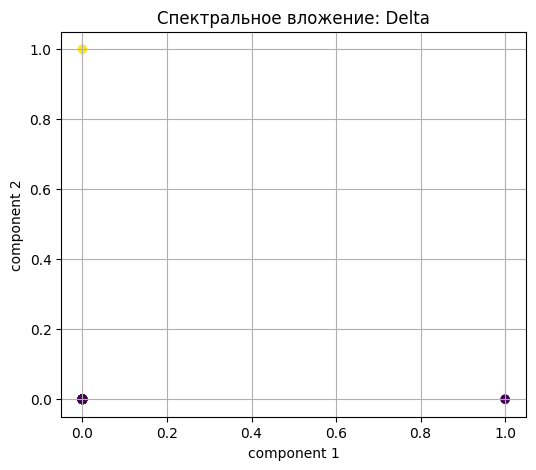

In [ ]:
def spectral_embedding(G, n_components=2, eps=1e-8):
    G_sym = (G + G.T) / 2

    eigvals, eigvecs = np.linalg.eigh(G_sym)

    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    positive_idx = eigvals > eps

    eigvals_pos = eigvals[positive_idx]
    eigvecs_pos = eigvecs[:, positive_idx]

    if len(eigvals_pos) < n_components:
        raise ValueError("недостаточно положительных собственных значений для двумерного вложения")

    eigvals_selected = eigvals_pos[:n_components]
    eigvecs_selected = eigvecs_pos[:, :n_components]

    Y = eigvecs_selected * np.sqrt(eigvals_selected)

    return Y


embedding_kernels = {
    "Linear": linear_kernel(X),
    "RBF gamma=1": rbf_kernel(X, gamma=1.0),
    "Delta": delta_kernel(X)
}

for name, G in embedding_kernels.items():
    Y_emb = spectral_embedding(G, n_components=2)

    plt.figure(figsize=(6, 5))
    plt.scatter(Y_emb[:, 0], Y_emb[:, 1], c = y)
    plt.title(f"спектральное вложение: {name}")
    plt.xlabel("component 1")
    plt.ylabel("component 2")
    plt.grid(True)
    plt.show()

## Дополнительная проверка на реальном датасете Iris



In [ ]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

X_iris = StandardScaler().fit_transform(X_iris)

iris_kernels = {
    "Linear": linear_kernel(X_iris),
    "RBF gamma=1": rbf_kernel(X_iris, gamma=1.0),
    "Delta": delta_kernel(X_iris),
    "Not equal": not_equal_kernel(X_iris),
    "Sigmoid k0=0, k1=1": sigmoid_kernel(X_iris, k0=0.0, k1=1.0)
}

iris_results = []

for name, G in iris_kernels.items():
    analysis = analyze_gram_matrix(G)

    iris_results.append({
        "Kernel": name,
        "||G - G.T||_F": analysis["asymmetry"],
        "lambda_min": analysis["lambda_min"],
        "negative eigenvalues": analysis["negative_count"],
        "PSD condition": analysis["is_psd"],
        "min random zTGz": analysis["random_min"],
        "negative random tests": analysis["random_negative_count"]
    })

iris_results_df = pd.DataFrame(iris_results)
iris_results_df

,Kernel,||G - G.T||_F,lambda_min,negative eigenvalues,PSD condition,min random zTGz,negative random tests
0,Linear,0.0,-1.625917e-13,0,True,3.482119,0
1,RBF gamma=1,0.0,1.140315e-18,0,True,46.353835,0
2,Delta,0.0,0.000000e+00,0,True,107.845312,0
3,Not equal,0.0,-1.986754e+00,148,False,-202.394140,691
4,"Sigmoid k0=0, k1=1",0.0,-1.845741e+01,74,False,-158.953875,161


# Вывод по 2 кейсу


В работе были рассмотрены пять функций сходства:

1. линейное ядро
2. RBF-ядро
3. дельта-ядро
4. ядро несовпадения
5. сигмоидальное ядро.

По результатам численной проверки:

- линейное ядро даёт положительно полуопределённую матрицу Грама
- RBF-ядро также даёт положительно полуопределённую матрицу Грама
- дельта-ядро является корректным ядром, так как его матрица Грама близка к единичной
- ядро несовпадения нарушает условие Мерсера, так как появляются отрицательные собственные значения
- сигмоидальное ядро не является гарантированно корректным: его поведение зависит от параметров $k_0$ и $k_1$

Отрицательное собственное значение означает нарушение условия Мерсера, потому что существует вектор $z$, для которого

$$
z^TGz<0
$$

Следовательно, матрица Грама не является положительно полуопределённой

Случайный тест с векторами $z$ полезен как дополнительная проверка, но он не заменяет спектральный анализ, потому что случайные векторы могут не попасть в направление собственного вектора, соответствующего отрицательному собственному значению

Положительная полуопределённость на одной выборке не доказывает выполнение теоремы Мерсера в полном виде. Для полного доказательства условие должно выполняться для любой конечной выборки

---

# Кейс 5. Метрические методы классификации


В этом разделе реализуются метрические алгоритмы классификации с нуля:

- 1NN
- kNN
- weighted-kNN
- окно Парзена фиксированной ширины
- окно Парзена переменной ширины
- подбор параметров по LOO
- проверка влияния масштабирования
- построение карт классификации
- профиль компактности
- отбор эталонов для ускорения 1NN


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_iris, load_wine, load_breast_cancer, make_moons, make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)


## 1. Базовая взвешенная метрика Минковского

Используем метрику

$$
\rho(x, x_i)=\left(\sum_{j=1}^{n} w_j |x_j-x_{ij}|^p\right)^{1/p}, \quad w_j>0, \quad p\ge 1
$$

Если веса признаков не заданы, считаем $w_j=1$


In [ ]:
def weighted_minkowski_distances(X_train, X_query, p=2, feature_weights=None):
    X_train = np.asarray(X_train, dtype=float)
    X_query = np.asarray(X_query, dtype=float)

    if feature_weights is None:
        feature_weights = np.ones(X_train.shape[1], dtype=float)
    feature_weights = np.asarray(feature_weights, dtype=float)

    diff = np.abs(X_query[:, None, :] - X_train[None, :, :]) ** p
    return np.sum(feature_weights[None, None, :] * diff, axis = 2) ** (1 / p)


def majority_vote(labels, scores=None):
    labels = np.asarray(labels)
    if scores is None:
        scores = np.ones(len(labels))
    scores = np.asarray(scores, dtype=float)

    class_scores = {}
    for y, s in zip(labels, scores):
        class_scores[y] = class_scores.get(y, 0.0) + s
    return sorted(class_scores.items(), key=lambda item: (-item[1], item[0]))[0][0]


## 2. Реализация 1NN, kNN и weighted-kNN с нуля

Общий принцип: для каждого нового объекта считаем расстояния до обучающих объектов, сортируем соседей и голосуем по классам


In [ ]:
def predict_knn(X_train, y_train, X_query, k=1, p=2, feature_weights=None, weighted=False, neighbor_weights=None):
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train)
    X_query = np.asarray(X_query, dtype=float)
    k = int(k)

    distances = weighted_minkowski_distances(X_train, X_query, p=p, feature_weights=feature_weights)
    order = np.argsort(distances, axis=1)[:, :k]

    if weighted:
        if neighbor_weights is None:
            neighbor_weights = 1 / np.arange(1, k + 1)
        neighbor_weights = np.asarray(neighbor_weights, dtype=float)
    else:
        neighbor_weights = np.ones(k)

    preds = []
    for row in order:
        preds.append(majority_vote(y_train[row], neighbor_weights))
    return np.array(preds)


def predict_1nn(X_train, y_train, X_query, p=2, feature_weights=None):
    return predict_knn(X_train, y_train, X_query, k=1, p=p, feature_weights=feature_weights)


## 3. Реализация окон Парзена с нуля

Реализуем несколько ядер:

- uniform
- triangular
- epanechnikov
- gaussian

Для фиксированного окна используется ширина $h$  
Для переменного окна нормировка выполняется на расстояние до $(k+1)$-го соседа


In [ ]:
def kernel_values(r, kernel='gaussian'):
    r = np.asarray(r, dtype=float)

    if kernel == 'uniform':
        return (np.abs(r) <= 1).astype(float) * 0.5
    if kernel == 'triangular':
        return np.maximum(1 - np.abs(r), 0.0)
    if kernel == 'epanechnikov':
        return 0.75 * np.maximum(1 - r ** 2, 0.0)
    if kernel == 'gaussian':
        return np.exp(-0.5 * r ** 2) / np.sqrt(2 * np.pi)

    raise ValueError(f'неизвестное ядро: {kernel}')


def predict_parzen_fixed(X_train, y_train, X_query, h=1.0, kernel='gaussian', p=2, feature_weights=None):
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train)
    X_query = np.asarray(X_query, dtype=float)

    distances = weighted_minkowski_distances(X_train, X_query, p=p, feature_weights=feature_weights)
    weights = kernel_values(distances / h, kernel=kernel)

    classes = np.unique(y_train)
    preds = []
    for row_weights, row_distances in zip(weights, distances):
        class_scores = [row_weights[y_train == c].sum() for c in classes]
        if np.max(class_scores) == 0:
            preds.append(y_train[np.argmin(row_distances)])
        else:
            preds.append(classes[np.argmax(class_scores)])
    return np.array(preds)


def predict_parzen_variable(X_train, y_train, X_query, k=5, kernel='gaussian', p=2, feature_weights=None):
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train)
    X_query = np.asarray(X_query, dtype=float)

    distances = weighted_minkowski_distances(X_train, X_query, p=p, feature_weights=feature_weights)
    sorted_distances = np.sort(distances, axis=1)
    k = int(k)
    h = sorted_distances[:, min(k, sorted_distances.shape[1] - 1)]
    h = np.maximum(h, 1e-12)

    weights = kernel_values(distances / h[:, None], kernel=kernel)
    classes = np.unique(y_train)

    preds = []
    for row_weights, row_distances in zip(weights, distances):
        class_scores = [row_weights[y_train == c].sum() for c in classes]
        if np.max(class_scores) == 0:
            preds.append(y_train[np.argmin(row_distances)])
        else:
            preds.append(classes[np.argmax(class_scores)])
    return np.array(preds)


## 4. LOO-контроль для подбора параметров

LOO = leave-one-out: каждый объект по очереди исключается из обучающей выборки и классифицируется по всем остальным объектам  
Доля ошибок на LOO используется как критерий выбора параметров $k$, $p$, $h$ и ядра


In [ ]:
def loo_error_knn(X, y, k=1, p=2, weighted=False, feature_weights=None):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)
    n = len(X)
    distances = weighted_minkowski_distances(X, X, p=p, feature_weights=feature_weights)
    np.fill_diagonal(distances, np.inf)
    order = np.argsort(distances, axis=1)[:, :k]

    if weighted:
        neighbor_weights = 1 / np.arange(1, k + 1)
    else:
        neighbor_weights = np.ones(k)

    preds = np.array([majority_vote(y[row], neighbor_weights) for row in order])
    return np.mean(preds != y)


def loo_error_parzen_fixed(X, y, h=1.0, kernel='gaussian', p=2, feature_weights=None):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)
    distances = weighted_minkowski_distances(X, X, p=p, feature_weights=feature_weights)
    np.fill_diagonal(distances, np.inf)
    weights = kernel_values(distances / h, kernel=kernel)
    classes = np.unique(y)

    preds = []
    for i in range(len(X)):
        class_scores = [weights[i, y == c].sum() for c in classes]
        if np.max(class_scores) == 0:
            preds.append(y[np.argmin(distances[i])])
        else:
            preds.append(classes[np.argmax(class_scores)])
    preds = np.array(preds)
    return np.mean(preds != y)


def loo_error_parzen_variable(X, y, k=5, kernel='gaussian', p=2, feature_weights=None):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)
    distances = weighted_minkowski_distances(X, X, p=p, feature_weights=feature_weights)
    np.fill_diagonal(distances, np.inf)
    sorted_distances = np.sort(distances, axis=1)
    h = sorted_distances[:, min(k, len(X) - 2)]
    h = np.maximum(h, 1e-12)
    weights = kernel_values(distances / h[:, None], kernel=kernel)
    classes = np.unique(y)

    preds = []
    for i in range(len(X)):
        class_scores = [weights[i, y == c].sum() for c in classes]
        if np.max(class_scores) == 0:
            preds.append(y[np.argmin(distances[i])])
        else:
            preds.append(classes[np.argmax(class_scores)])
    preds = np.array(preds)
    return np.mean(preds != y)


## 5. Реальные датасеты и влияние масштабирования

Берем три реальные задачи из `sklearn.datasets`

- Iris
- Wine
- Breast Cancer Wisconsin

Проверяем качество kNN до и после стандартизации признаков


In [ ]:
datasets = {
    'Iris': load_iris(return_X_y=True),
    'Wine': load_wine(return_X_y=True),
    'Breast Cancer': load_breast_cancer(return_X_y=True),
}

scaling_rows = []
for name, (X, y) in datasets.items():
    err_raw = loo_error_knn(X, y, k=5, p=2, weighted=False)
    X_scaled = StandardScaler().fit_transform(X)
    err_scaled = loo_error_knn(X_scaled, y, k=5, p=2, weighted=False)
    scaling_rows.append({
        'dataset': name,
        'LOO error without scaling': err_raw,
        'LOO accuracy without scaling': 1 - err_raw,
        'LOO error with scaling': err_scaled,
        'LOO accuracy with scaling': 1 - err_scaled,
    })

scaling_df = pd.DataFrame(scaling_rows)
scaling_df


,dataset,LOO error without scaling,LOO accuracy without scaling,LOO error with scaling,LOO accuracy with scaling
0,Iris,0.033333,0.966667,0.053333,0.946667
1,Wine,0.303371,0.696629,0.028090,0.971910
2,Breast Cancer,0.066784,0.933216,0.029877,0.970123


**Промежуточный вывод**  
Метрические методы чувствительны к масштабу признаков. Если один признак имеет большие численные значения, он начинает доминировать в расстоянии Минковского. Поэтому для Wine и Breast Cancer стандартизация обычно заметно улучшает или стабилизирует качество


## 6. Подбор параметров $k$, $p$, $h$ и ядра по LOO

Для каждого датасета подбираем:

- лучшее $k$ для kNN
- лучшее $k$ для weighted-kNN
- лучшее $p$ в метрике Минковского
- лучшее $h$ и ядро для окна Парзена фиксированной ширины
- лучшее $k$ и ядро для окна Парзена переменной ширины


In [ ]:
k_grid = list(range(1, 31, 2))
p_grid = [1, 1.5, 2, 3, 4]
h_grid = np.linspace(0.1, 3.0, 20)
kernels = ['uniform', 'triangular', 'epanechnikov', 'gaussian']

summary_rows = []
curves = {}

for name, (X_raw, y) in datasets.items():
    X = StandardScaler().fit_transform(X_raw)

    knn_errors = [loo_error_knn(X, y, k=k, p=2, weighted=False) for k in k_grid]
    wknn_errors = [loo_error_knn(X, y, k=k, p=2, weighted=True) for k in k_grid]
    p_errors = [loo_error_knn(X, y, k=5, p=p, weighted=False) for p in p_grid]

    best_knn_idx = int(np.argmin(knn_errors))
    best_wknn_idx = int(np.argmin(wknn_errors))
    best_p_idx = int(np.argmin(p_errors))

    parzen_fixed_results = []
    for kernel in kernels:
        for h in h_grid:
            err = loo_error_parzen_fixed(X, y, h=h, kernel=kernel, p=2)
            parzen_fixed_results.append((err, h, kernel))
    best_fixed_err, best_h, best_fixed_kernel = min(parzen_fixed_results, key=lambda t: t[0])

    parzen_variable_results = []
    for kernel in kernels:
        for k in k_grid:
            err = loo_error_parzen_variable(X, y, k=k, kernel=kernel, p=2)
            parzen_variable_results.append((err, k, kernel))
    best_var_err, best_var_k, best_var_kernel = min(parzen_variable_results, key=lambda t: t[0])

    summary_rows.append({
        'dataset': name,
        'best kNN k': k_grid[best_knn_idx],
        'best kNN LOO acc': 1 - knn_errors[best_knn_idx],
        'best weighted-kNN k': k_grid[best_wknn_idx],
        'best weighted-kNN LOO acc': 1 - wknn_errors[best_wknn_idx],
        'best p for k=5': p_grid[best_p_idx],
        'best p LOO acc': 1 - p_errors[best_p_idx],
        'best fixed Parzen h': round(float(best_h), 3),
        'best fixed Parzen kernel': best_fixed_kernel,
        'best fixed Parzen LOO acc': 1 - best_fixed_err,
        'best variable Parzen k': best_var_k,
        'best variable Parzen kernel': best_var_kernel,
        'best variable Parzen LOO acc': 1 - best_var_err,
    })

    curves[name] = {
        'k': k_grid,
        'knn_errors': knn_errors,
        'wknn_errors': wknn_errors,
        'p': p_grid,
        'p_errors': p_errors,
    }

params_summary_df = pd.DataFrame(summary_rows)
params_summary_df


,dataset,best kNN k,best kNN LOO acc,best weighted-kNN k,best weighted-kNN LOO acc,best p for k=5,best p LOO acc,best fixed Parzen h,best fixed Parzen kernel,best fixed Parzen LOO acc,best variable Parzen k,best variable Parzen kernel,best variable Parzen LOO acc
0,Iris,13,0.966667,9,0.953333,1,0.953333,0.863,uniform,0.960000,15,uniform,0.973333
1,Wine,11,0.977528,7,0.960674,2,0.971910,2.389,gaussian,0.983146,1,gaussian,0.983146
2,Breast Cancer,5,0.970123,25,0.971880,2,0.970123,2.847,uniform,0.966608,3,uniform,0.971880


## 7. График зависимости LOO-ошибки от числа соседей $k$


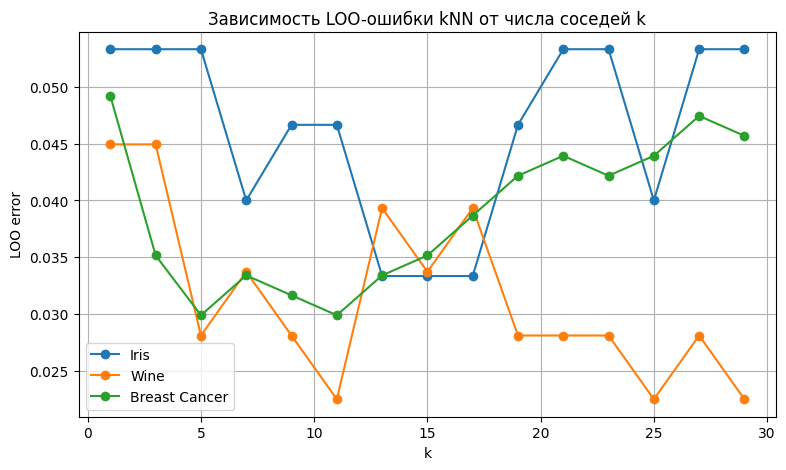

In [ ]:
plt.figure(figsize=(9, 5))
for name in curves:
    plt.plot(curves[name]['k'], curves[name]['knn_errors'], marker='o', label=name)
plt.xlabel('k')
plt.ylabel('LOO error')
plt.title('зависимость LOO ошибки kNN от числа соседей k')
plt.grid(True)
plt.legend()
plt.show()


## 8. График зависимости LOO-ошибки от ширины окна $h$

Для наглядности строим график для датасета Iris и фиксированного окна Парзена при разных ядрах


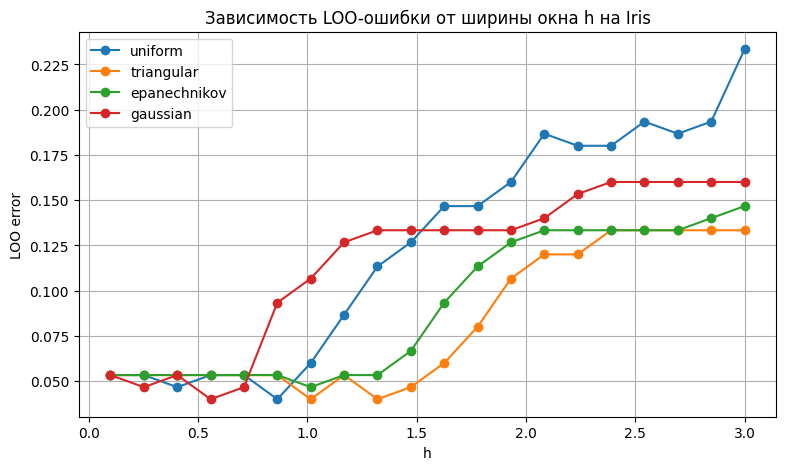

In [ ]:
X_iris, y_iris = load_iris(return_X_y=True)
X_iris = StandardScaler().fit_transform(X_iris)

plt.figure(figsize=(9, 5))
for kernel in kernels:
    errors = [loo_error_parzen_fixed(X_iris, y_iris, h=h, kernel=kernel, p=2) for h in h_grid]
    plt.plot(h_grid, errors, marker='o', label=kernel)
plt.xlabel('h')
plt.ylabel('LOO error')
plt.title('зависимость LOO ошибки от ширины окна h на Iris')
plt.grid(True)
plt.legend()
plt.show()


## 9. График зависимости качества от параметра $p$ в метрике Минковского


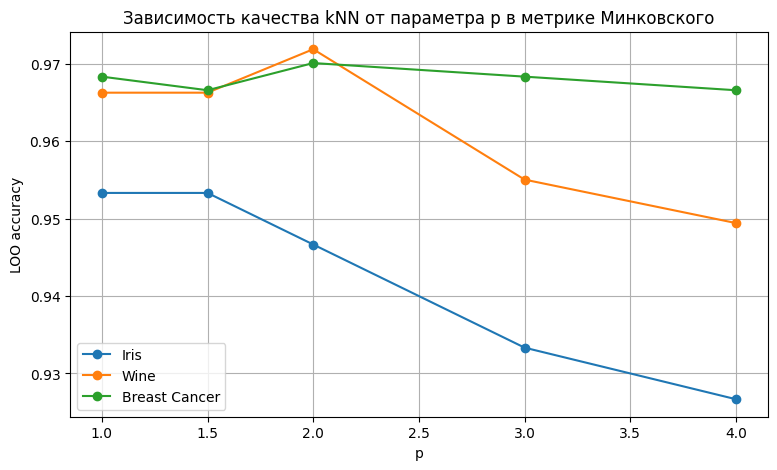

In [ ]:
plt.figure(figsize=(9, 5))
for name in curves:
    acc = [1 - e for e in curves[name]['p_errors']]
    plt.plot(curves[name]['p'], acc, marker='o', label=name)
plt.xlabel('p')
plt.ylabel('LOO accuracy')
plt.title('зависимость качества kNN от параметра p в метрике Минковского')
plt.grid(True)
plt.legend()
plt.show()


## 10. Карты классификации и границы решения на двумерном датасете

Используем `make_moons`, потому что это нелинейная задача, на которой хорошо видны различия между маленьким и большим $k$, а также между узким и широким окном Парзена


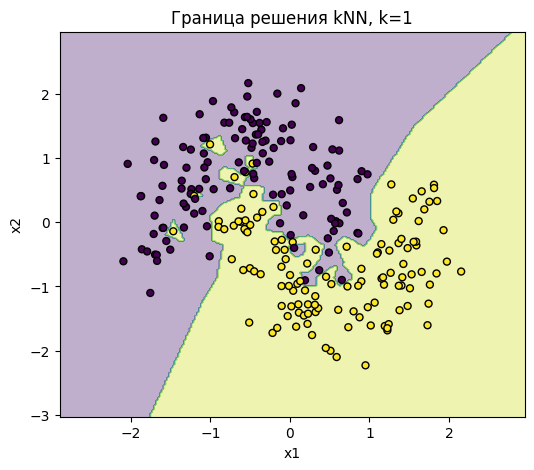

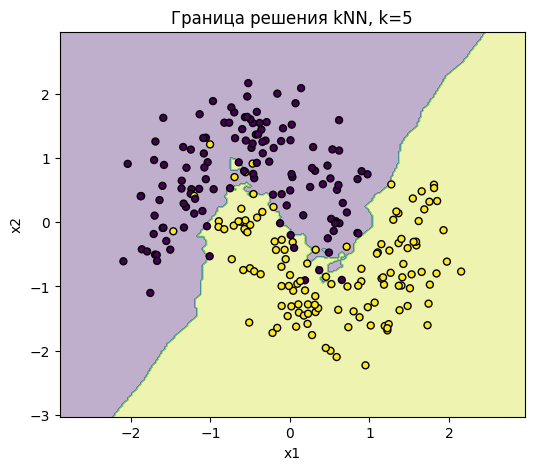

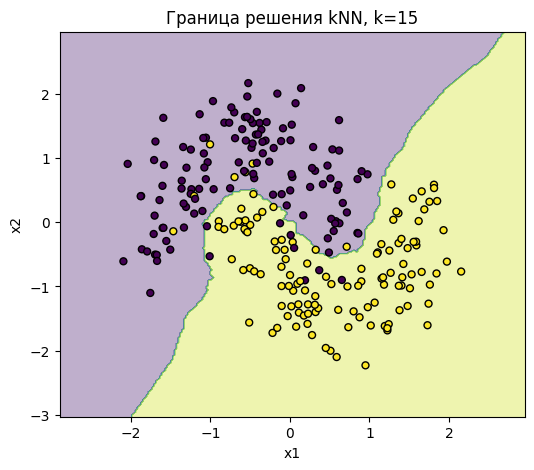

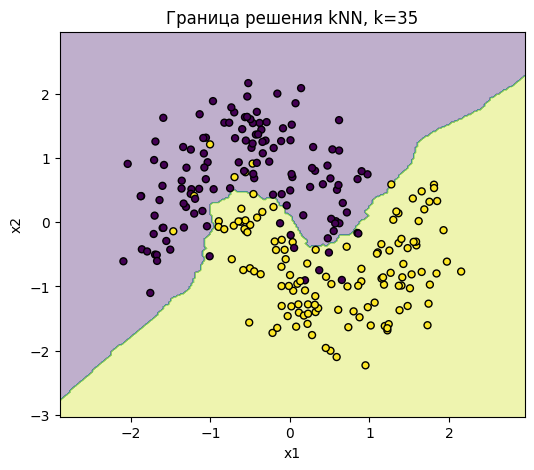

In [ ]:
X_moons, y_moons = make_moons(n_samples=250, noise=0.25, random_state=42)
X_moons = StandardScaler().fit_transform(X_moons)

x_min, x_max = X_moons[:, 0].min() - 0.8, X_moons[:, 0].max() + 0.8
y_min, y_max = X_moons[:, 1].min() - 0.8, X_moons[:, 1].max() + 0.8
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
grid = np.c_[xx.ravel(), yy.ravel()]

for k in [1, 5, 15, 35]:
    Z = predict_knn(X_moons, y_moons, grid, k=k, p=2).reshape(xx.shape)
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.35)
    plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, edgecolor='k', s=25)
    plt.title(f'граница решения kNN, k={k}')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.show()


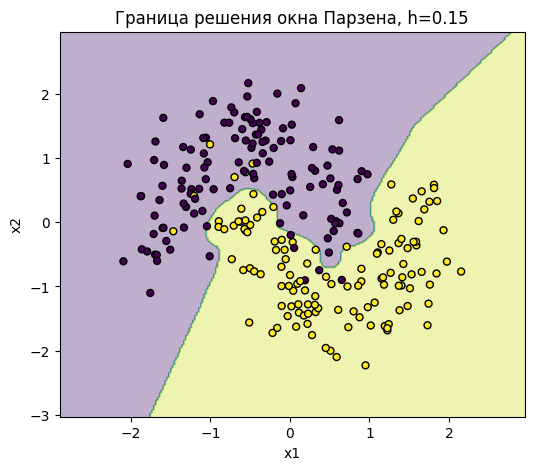

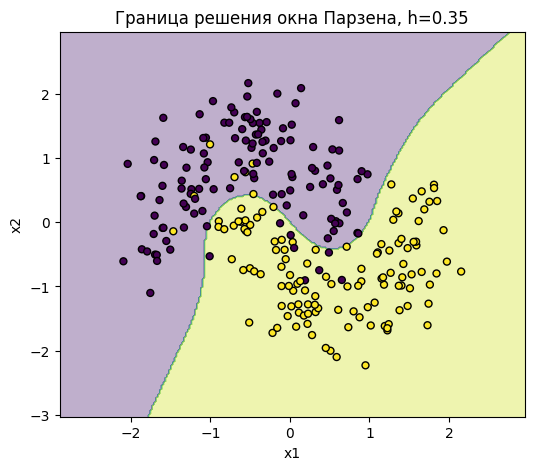

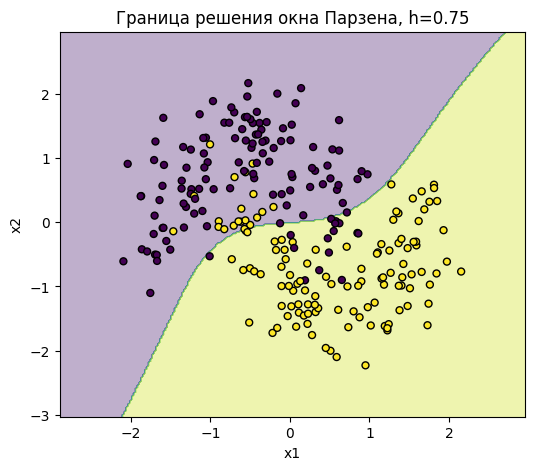

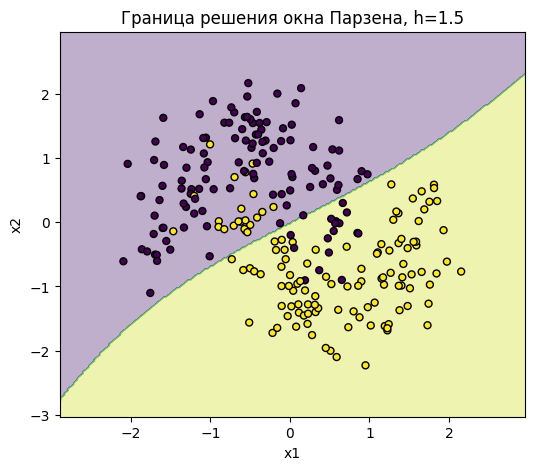

In [ ]:
for h in [0.15, 0.35, 0.75, 1.5]:
    Z = predict_parzen_fixed(X_moons, y_moons, grid, h=h, kernel='gaussian', p=2).reshape(xx.shape)
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.35)
    plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, edgecolor='k', s=25)
    plt.title(f'граница решения окна Парзена, h={h}')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.show()


**Вывод по картам классификации**  
Малые значения $k$ и $h$ дают очень гибкую границу, которая хорошо подстраивается под обучающую выборку, но может переобучаться на шум. Большие значения $k$ и $h$ сглаживают границу, делают алгоритм устойчивее, но при слишком сильном сглаживании возможна потеря важной локальной структуры данных


## 11. Когда weighted-kNN устойчивее обычного kNN

Проверим задачу с шумными признаками и выбросами. weighted-kNN должен быть устойчивее, потому что ближайшие соседи получают больший вклад, а дальние соседи из окна $k$ меньше влияют на итоговое решение


In [ ]:
def add_outliers(X, y, n_outliers=40, random_state=42):
    rng = np.random.default_rng(random_state)
    x_min = X.min(axis=0) - 2
    x_max = X.max(axis=0) + 2
    X_out = rng.uniform(x_min, x_max, size=(n_outliers, X.shape[1]))
    y_out = rng.integers(0, len(np.unique(y)), size=n_outliers)
    return np.vstack([X, X_out]), np.concatenate([y, y_out])

X_syn, y_syn = make_classification(
    n_samples=450,
    n_features=8,
    n_informative=2,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    class_sep=1.0,
    flip_y=0.08,
    random_state=42,
)
X_syn = StandardScaler().fit_transform(X_syn)
X_noisy, y_noisy = add_outliers(X_syn, y_syn, n_outliers=70, random_state=42)

rows = []
for k in [3, 5, 9, 15, 25, 35]:
    err_knn = loo_error_knn(X_noisy, y_noisy, k=k, p=2, weighted=False)
    err_wknn = loo_error_knn(X_noisy, y_noisy, k=k, p=2, weighted=True)
    rows.append({
        'k': k,
        'kNN LOO accuracy': 1 - err_knn,
        'weighted-kNN LOO accuracy': 1 - err_wknn,
        'weighted minus usual': (1 - err_wknn) - (1 - err_knn),
    })

stability_df = pd.DataFrame(rows)
stability_df


,k,kNN LOO accuracy,weighted-kNN LOO accuracy,weighted minus usual
0,3,0.792308,0.780769,-0.011538
1,5,0.819231,0.794231,-0.025000
2,9,0.830769,0.794231,-0.036538
3,15,0.832692,0.805769,-0.026923
4,25,0.826923,0.811538,-0.015385
5,35,0.834615,0.813462,-0.021154


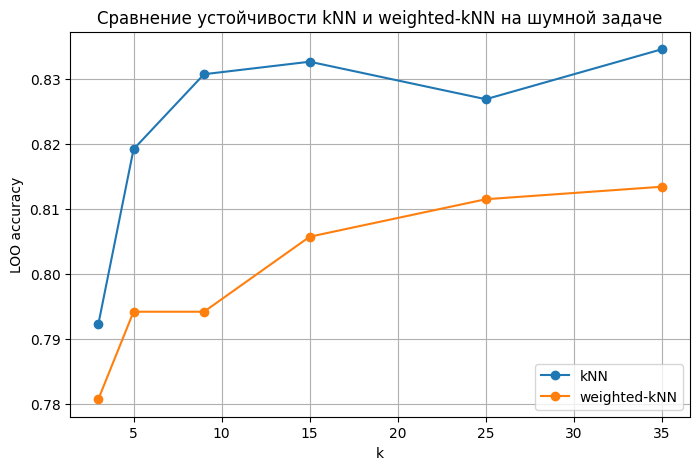

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(stability_df['k'], stability_df['kNN LOO accuracy'], marker='o', label='kNN')
plt.plot(stability_df['k'], stability_df['weighted-kNN LOO accuracy'], marker='o', label='weighted-kNN')
plt.xlabel('k')
plt.ylabel('LOO accuracy')
plt.title('сравнение устойчивости kNN и weighted-kNN на шумной задаче')
plt.grid(True)
plt.legend()
plt.show()


**Вывод**  
weighted-kNN особенно полезен при средних и больших $k$, когда в число соседей могут попадать объекты из другой области или выбросы. Убывающие веса уменьшают влияние дальних соседей и делают решение более локальным


## 12. Профиль компактности $\Pi(m)$

Профиль компактности показывает, как часто класс объекта отличается от класса его $m$-го соседа:

$$
\Pi(m)=\frac{1}{L}\sum_{i=1}^{L}[y_i\ne y_i^{(m)}]
$$

Если профиль быстро растет, классы плохо отделены и 1NN обычно работает хуже. Если первые соседи почти всегда имеют тот же класс, задача хорошо подходит для метрических методов


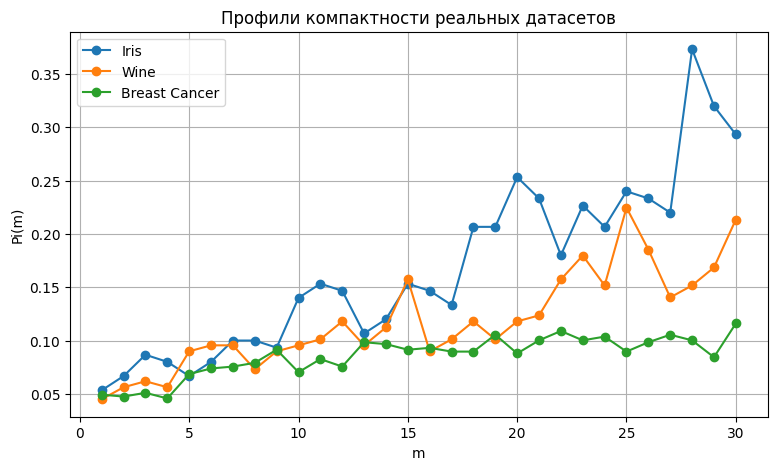

,dataset,Pi(1),mean Pi(1..10),1NN LOO accuracy
0,Iris,0.053333,0.086667,0.946667
1,Wine,0.044944,0.075843,0.955056
2,Breast Cancer,0.049209,0.065202,0.950791


In [ ]:
def compactness_profile(X, y, max_m=30, p=2):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)
    distances = weighted_minkowski_distances(X, X, p=p)
    np.fill_diagonal(distances, np.inf)
    order = np.argsort(distances, axis=1)

    ms = np.arange(1, max_m + 1)
    profile = []
    for m in ms:
        m_neighbor = order[:, m - 1]
        profile.append(np.mean(y != y[m_neighbor]))
    return ms, np.array(profile)

profile_rows = []
plt.figure(figsize=(9, 5))
for name, (X_raw, y) in datasets.items():
    X = StandardScaler().fit_transform(X_raw)
    max_m = min(30, len(X) - 1)
    ms, profile = compactness_profile(X, y, max_m=max_m, p=2)
    err_1nn = loo_error_knn(X, y, k=1, p=2)
    profile_rows.append({
        'dataset': name,
        'Pi(1)': profile[0],
        'mean Pi(1..10)': profile[:10].mean(),
        '1NN LOO accuracy': 1 - err_1nn,
    })
    plt.plot(ms, profile, marker='o', label=name)

plt.xlabel('m')
plt.ylabel('Pi(m)')
plt.title('профили компактности реальных датасетов')
plt.grid(True)
plt.legend()
plt.show()

profile_df = pd.DataFrame(profile_rows)
profile_df


In [ ]:
correlation = profile_df['mean Pi(1..10)'].corr(profile_df['1NN LOO accuracy'])
print(f'корреляция между средней компактностью Pi(1..10) и качеством 1NN: {correlation:.4f}')


Корреляция между средней компактностью Pi(1..10) и качеством 1NN: -0.4959


**Вывод по профилю компактности**  
Чем меньше значения $\Pi(m)$ на первых соседях, тем чаще ближайшие объекты принадлежат правильному классу. Поэтому низкий профиль компактности обычно соответствует высокому качеству 1NN. Корреляция с accuracy получается отрицательной: при росте $\Pi(m)$ качество 1NN падает


## 13. Жадный отбор эталонов

Цель отбора эталонов: заменить полную обучающую выборку меньшим подмножеством $\Omega\subset X^\ell$, чтобы ускорить классификацию без сильной потери качества

Реализуем два простых алгоритма:

1. **Последовательное удаление**: пробуем удалить объект, если качество на валидации не падает сильнее допустимого порога
2. **Последовательное добавление**: начинаем с одного объекта каждого класса и добавляем те объекты, которые улучшают качество сильнее всего


In [ ]:
def validation_accuracy_1nn(X_ref, y_ref, X_val, y_val, p=2):
    pred = predict_1nn(X_ref, y_ref, X_val, p=p)
    return accuracy_score(y_val, pred)


def greedy_delete_prototypes(X_train, y_train, X_val, y_val, max_drop=0.01, p=2, max_passes=2):
    selected = list(range(len(X_train)))
    best_acc = validation_accuracy_1nn(X_train[selected], y_train[selected], X_val, y_val, p=p)

    for _ in range(max_passes):
        changed = False
        for idx in selected.copy():
            if len(selected) <= len(np.unique(y_train)):
                break
            candidate = [j for j in selected if j != idx]
            if len(np.unique(y_train[candidate])) < len(np.unique(y_train)):
                continue
            acc = validation_accuracy_1nn(X_train[candidate], y_train[candidate], X_val, y_val, p=p)
            if acc >= best_acc - max_drop:
                selected = candidate
                best_acc = acc
                changed = True
        if not changed:
            break
    return np.array(selected), best_acc


def greedy_add_prototypes(X_train, y_train, X_val, y_val, target_size=None, p=2):
    classes = np.unique(y_train)
    selected = []
    for c in classes:
        candidates = np.where(y_train == c)[0]
        selected.append(candidates[0])

    if target_size is None:
        target_size = max(len(classes), int(0.25 * len(X_train)))

    selected = list(dict.fromkeys(selected))
    remaining = [i for i in range(len(X_train)) if i not in selected]
    best_acc = validation_accuracy_1nn(X_train[selected], y_train[selected], X_val, y_val, p=p)

    while len(selected) < target_size and remaining:
        best_candidate = None
        best_candidate_acc = -1
        pool = remaining if len(remaining) <= 80 else list(np.random.choice(remaining, 80, replace=False))
        for idx in pool:
            candidate_selected = selected + [idx]
            acc = validation_accuracy_1nn(X_train[candidate_selected], y_train[candidate_selected], X_val, y_val, p=p)
            if acc > best_candidate_acc:
                best_candidate_acc = acc
                best_candidate = idx
        selected.append(best_candidate)
        remaining.remove(best_candidate)
        best_acc = max(best_acc, best_candidate_acc)
    return np.array(selected), best_acc


In [ ]:
prototype_rows = []

for name in ['Iris', 'Wine', 'Breast Cancer']:
    X_raw, y = datasets[name]
    X = StandardScaler().fit_transform(X_raw)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    X_base, X_val, y_base, y_val = train_test_split(
        X_train, y_train, test_size=0.3, random_state=42, stratify=y_train
    )

    t0 = time.perf_counter()
    full_pred = predict_1nn(X_base, y_base, X_test, p=2)
    full_time = time.perf_counter() - t0
    full_acc = accuracy_score(y_test, full_pred)

    del_idx, del_val_acc = greedy_delete_prototypes(X_base, y_base, X_val, y_val, max_drop=0.01, p=2)
    t0 = time.perf_counter()
    del_pred = predict_1nn(X_base[del_idx], y_base[del_idx], X_test, p=2)
    del_time = time.perf_counter() - t0
    del_acc = accuracy_score(y_test, del_pred)

    add_idx, add_val_acc = greedy_add_prototypes(X_base, y_base, X_val, y_val, target_size=max(len(np.unique(y)), int(0.25 * len(X_base))), p=2)
    t0 = time.perf_counter()
    add_pred = predict_1nn(X_base[add_idx], y_base[add_idx], X_test, p=2)
    add_time = time.perf_counter() - t0
    add_acc = accuracy_score(y_test, add_pred)

    prototype_rows.extend([
        {
            'dataset': name,
            'method': 'full 1NN',
            'n_prototypes': len(X_base),
            'test accuracy': full_acc,
            'prediction time sec': full_time,
        },
        {
            'dataset': name,
            'method': 'greedy deletion',
            'n_prototypes': len(del_idx),
            'test accuracy': del_acc,
            'prediction time sec': del_time,
        },
        {
            'dataset': name,
            'method': 'greedy addition',
            'n_prototypes': len(add_idx),
            'test accuracy': add_acc,
            'prediction time sec': add_time,
        },
    ])

prototype_df = pd.DataFrame(prototype_rows)
prototype_df


,dataset,method,n_prototypes,test accuracy,prediction time sec
0,Iris,full 1NN,73,0.911111,0.001264
1,Iris,greedy deletion,5,0.955556,0.000181
2,Iris,greedy addition,18,0.888889,0.000222
3,Wine,full 1NN,86,0.925926,0.000617
4,Wine,greedy deletion,6,0.888889,0.000220
5,Wine,greedy addition,21,0.944444,0.000295
6,Breast Cancer,full 1NN,278,0.947368,0.009200
7,Breast Cancer,greedy deletion,2,0.906433,0.000569
8,Breast Cancer,greedy addition,69,0.964912,0.002396


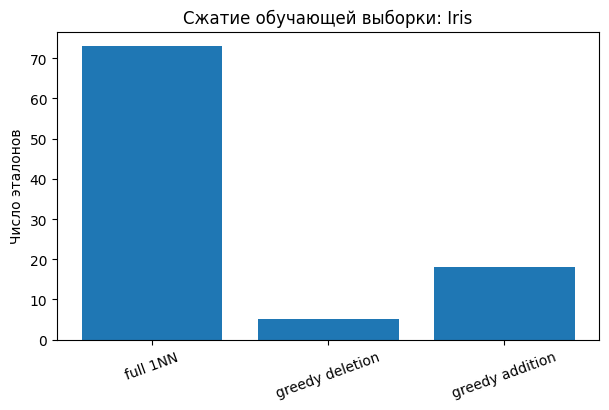

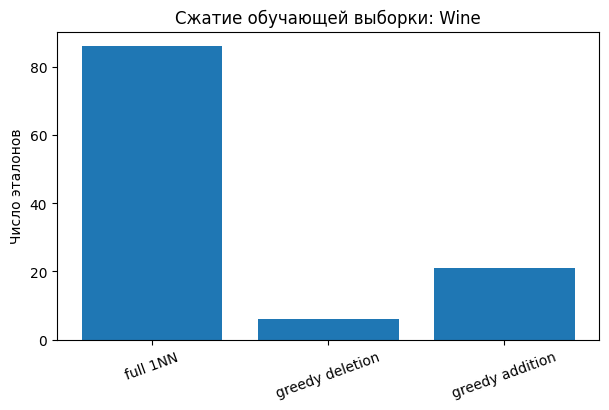

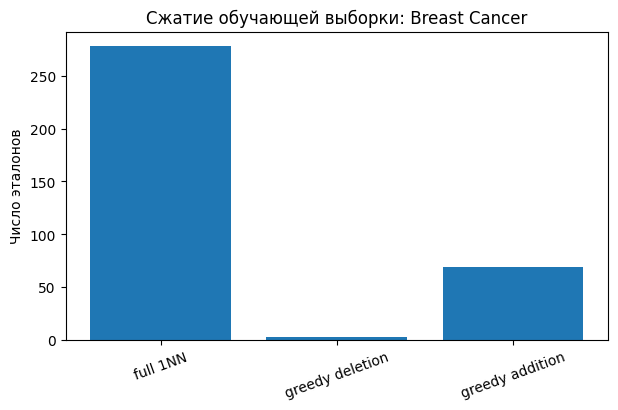

In [ ]:
for name in prototype_df['dataset'].unique():
    part = prototype_df[prototype_df['dataset'] == name]
    plt.figure(figsize=(7, 4))
    plt.bar(part['method'], part['n_prototypes'])
    plt.ylabel('число эталонов')
    plt.title(f'сжатие обучающей выборки: {name}')
    plt.xticks(rotation=20)
    plt.show()


**Вывод по эталонам**  
Отбор эталонов уменьшает количество объектов, с которыми сравнивается новый объект. Поэтому время предсказания падает. При этом качество может почти не измениться, если удаляются дублирующие или неинформативные объекты. Но слишком агрессивный отбор ухудшает качество, потому что локальная структура классов теряется


## 14. Итоговые выводы по кейсу 5

1. **Число соседей $k$ управляет балансом между переобучением и сглаживанием.** При маленьком $k$ классификатор чувствителен к шуму и отдельным выбросам. При большом $k$ граница решения становится устойчивее, но может стать слишком грубой

2. **Масштабирование признаков критично для метрических методов.** Без стандартизации признаки с большими численными значениями получают неявно больший вес в расстоянии Минковского. После масштабирования качество обычно становится выше и стабильнее

3. **Параметр $p$ меняет геометрию расстояния.** При $p=1$ используется манхэттенская метрика, при $p=2$ — евклидова. Оптимальное значение зависит от структуры данных, поэтому его разумно выбирать по LOO

4. **Ширина окна Парзена $h$ играет роль степени сглаживания.** Малое $h$ делает классификатор очень локальным и чувствительным к шуму. Большое $h$ учитывает слишком много объектов и может размывать границы классов

5. **weighted-kNN часто устойчивее обычного kNN при шуме и выбросах.** Дальние соседи получают меньшие веса, поэтому они слабее влияют на итоговое решение

6. **Профиль компактности связан с качеством 1NN.** Если ближайшие соседи часто имеют тот же класс, задача хорошо решается метрическими методами. Если $\Pi(m)$ быстро растет, классы перемешаны, и качество 1NN падает

7. **Отбор эталонов ускоряет классификацию.** Жадное удаление или добавление позволяет уменьшить обучающую выборку. Если эталоны выбраны аккуратно, качество почти сохраняется, а время предсказания снижается
